## Simple Workflow

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
BASE_URL = os.getenv('OPENAI_BASE_URL')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' # Set the LangSmith project name

In [3]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    api_key= API_KEY,
    base_url = BASE_URL,
    model = 'gpt-5.1'
)

In [4]:
from typing import TypedDict
from langgraph.graph import START, END, StateGraph

### Simple workflow 
- Without LLM 

In [5]:
# Every LangGraph Workflow will ttypically start wth a state definition

class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float

In [11]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = round(weight/(height**2), 2)
    state['bmi'] = bmi
    return state


calculate_bmi({'height_m':1.78, 'weight_kg':76.5})

{'height_m': 1.78, 'weight_kg': 76.5, 'bmi': 24.14}

In [13]:
# Creaitng a graph using the above function

graph = StateGraph(BMIState)

# Adding nodes
graph.add_node('calculate_bmi', calculate_bmi)

# Define the edges for the graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', END)

workflow = graph.compile()

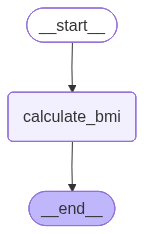

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [18]:
initial_state : BMIState = {
    'weight_kg': 76.2,
    'height_m': 1.77
}

final_state = workflow.invoke(initial_state)

print(f'BMI: {final_state['bmi']}')

BMI: 24.32


In [25]:
# Trying Pydantic for the same task

from pydantic import BaseModel, Field
from typing import Optional

class PyBMI(BaseModel):
    weight: float = Field(description='Weight of the person in kg')
    height: float = Field(description='Height of the person in m')
    bmi: Optional[float] = Field(description='calculted BMI', default=None)

def calculate_bmi_pydantic(state: PyBMI) -> PyBMI:
    height = state.height
    weight = state.weight
    bmi = weight/(height**2)
    state.bmi = round(bmi, 2)
    return state

graph = StateGraph(PyBMI)
graph.add_node('cal_bmi', calculate_bmi_pydantic)
graph.add_edge(START, 'cal_bmi')
graph.add_edge('cal_bmi', END)

workflow = graph.compile()

initial_state = PyBMI(weight=76, height=1.8)
final_state = PyBMI(**workflow.invoke(initial_state))
print(f'BMI: {final_state.bmi}')

BMI: 23.46


### Simple LLM workflow

In [26]:
# Checking the model
model.invoke('Ping')

AIMessage(content='Pong.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 7, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 30, 'engine_ttft_ms': 136, 'engine_ttlt_ms': 521, 'pre_inference_ms': 95, 'service_tbt_ms': 30, 'service_ttft_ms': 361, 'service_ttlt_ms': 740, 'total_duration_ms': 656, 'user_visible_ttft_ms': 266}}, 'model_provider': 'openai', 'model_name': 'gpt-5.1-2025-11-13', 'system_fingerprint': None, 'id': 'chatcmpl-Dh7lK5aq49VUTPq2kkaldS79pAssx', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3ed0-80fb-7270-a530-aef277949780-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 13, 'total_tokens': 20, 'input_token

In [27]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

class LLMState(TypedDict):
    question: str
    answer: str

def llm_qa(state: LLMState) -> LLMState:
    question = state['question']
    response = model.invoke(question)
    state['answer'] = response.content
    return state

# Tesing the llm_qa
llm_qa({'question': 'How are you'})

{'question': 'How are you',
 'answer': 'I’m functioning well, thanks for asking. How can I help you today?'}

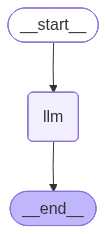

In [ ]:
graph = StateGraph(LLMState)
graph.add_node('llm',llm_qa)
graph.add_edge(START, 'llm')
graph.add_edge('llm', END)

workflow = graph.compile()
Image(workflow.get_graph().draw_mermaid_png())

In [31]:
initial_state = {'question': 'What is AI Agent in short?'}
final_state = workflow.invoke(initial_state)
print(final_state['answer'])

An AI agent is a software program that can perceive its environment (through data), decide what to do (using rules or models), and take actions to achieve goals—often autonomously and repeatedly.


### State Passing
From one node to other

In [ ]:
class TypedDictState(TypedDict):
    msg : str

def hello(state: TypedDictState):
    print(f'Message from hello: {state['msg']}')
    return {'msg': f'Hello {state['msg']}'}

def bye(state: TypedDictState) -> TypedDictState:
    print(f'Message from bye: {state["msg"]}')
    return {'msg': f'Bye {' '.join(state['msg'].split()[1:])}'}

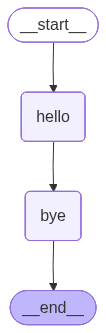

In [39]:
graph = StateGraph(TypedDictState)
graph.add_node('hello', hello)
graph.add_node('bye', bye)
# graph.add_edge(START, 'hello')
graph.add_edge('hello', 'bye')
graph.add_edge('bye', END)
graph.set_entry_point('hello')

workflow = graph.compile()
workflow

In [40]:
workflow.invoke({'msg':'Ayush'})

Message from hello: Ayush
Message from bye: Hello Ayush


{'msg': 'Bye Ayush'}

In [42]:
# No Data type binding
workflow.invoke({'msg':123})

Message from hello: 123
Message from bye: Hello 123


{'msg': 'Bye 123'}

### Using DataClass

In [47]:
from dataclasses import dataclass
@dataclass
class DataClassState:
    message: str

def hello(state: DataClassState) -> DataClassState:
    print(f'Message from hello: {state.message}')
    return {'msg': f'Hello {state.message}'}
def bye(state: DataClassState) -> DataClassState :
    print(f'Message from bye: {state.message}')
    return {'msg': f'Bye {' '.join(state.message.split()[1:])}'}

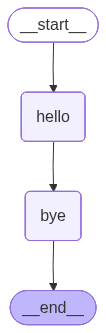

In [48]:
graph = StateGraph(DataClassState)
graph.add_node('hello', hello)
graph.add_node('bye', bye)
# graph.add_edge(START, 'hello')
graph.add_edge('hello', 'bye')
graph.add_edge('bye', END)
graph.set_entry_point('hello')

workflow2 = graph.compile()
workflow2

In [49]:
initial_state = DataClassState(message = 'Ayush')
final_state = workflow2.invoke(initial_state)
final_state

Message from hello: Ayush
Message from bye: Ayush


{'message': 'Ayush'}

### Pydantic

In [52]:
class PyState(BaseModel):
    message : str = Field(min_length=3, max_length = 100)

def hello(state: PyState) -> PyState:
    print(f'Message from hello: {state.message}')
    return {'msg': f'Hello {state.message}'}
def bye(state: PyState) -> PyState :
    print(f'Message from bye: {state.message}')
    return {'msg': f'Bye {' '.join(state.message.split()[1:])}'}

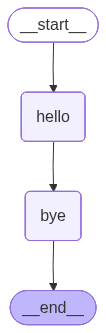

In [53]:
graph = StateGraph(PyState)
graph.add_node('hello', hello)
graph.add_node('bye', bye)
# graph.add_edge(START, 'hello')
graph.add_edge('hello', 'bye')
graph.add_edge('bye', END)
graph.set_entry_point('hello')

workflow2 = graph.compile()
workflow2

In [56]:
workflow2.invoke({'message': 'Ayush'})

Message from hello: Ayush
Message from bye: Ayush


{'message': 'Ayush'}

In [58]:
# workflow2.invoke({'message': 123}) -> Validation Error